# Castings Dataset Exploration

Short exploratory notebook for the castings technical dataset in `data/raw/`.
It uses the project loader so parsing stays aligned with later pipeline code.

In [1]:
import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not find project root containing 'src'.")

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.data.load_parts as load_parts_module

load_parts_module = importlib.reload(load_parts_module)
load_castings_dataset = load_parts_module.load_castings_dataset

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

In [2]:
dataset = load_castings_dataset()
df = dataset.features.copy()
df["target"] = dataset.target

print(f"Dataset: {dataset.dataset_name}")
print(f"Rows: {df.shape[0]}")
print(f"Features: {dataset.features.shape[1]}")
df.head()

Dataset: castings
Rows: 189
Features: 12


,ID,Vol,wgt,proc,mach,coat,paint,cmplx,inspection,packaging,Material,Type of casting,target
0,1,220,5.443,1,0.5,1,0,1,1,0,EN-GJS-700-02,1,16.1
1,2,220,5.443,1,0.5,1,0,1,1,0,EN-GJS-700-02,1,16.1
2,3,110,263.991,0,0.2,1,0,1,1,0,EN-GJL-250,1,412.0
3,4,110,263.991,0,0.2,1,0,1,1,0,EN-GJL-250,1,412.0
4,5,1384,10.115,0,0.2,0,0,1,1,0,EN-GJS-900-2,1,27.66


In [3]:
summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "n_unique": df.nunique(dropna=True),
    }
)
summary

,dtype,missing_values,n_unique
ID,Int64,0,189
Vol,Int64,11,124
wgt,Float64,3,138
proc,Int64,0,2
mach,Float64,0,4
coat,Int64,0,2
paint,Int64,0,2
cmplx,Int64,1,3
inspection,Int64,0,4
packaging,Int64,0,2


In [4]:
numeric_summary = df.describe(include=["number"]).transpose()
numeric_summary

,count,mean,std,min,25%,50%,75%,max
ID,189.0,95.0,54.703748,1.0,48.0,95.0,142.0,189.0
Vol,178.0,2518.837079,6529.591724,1.0,51.0,264.0,1420.5,43893.0
wgt,186.0,1598.637081,2294.518968,0.073,52.2,362.1935,2833.592,10000.0
proc,189.0,0.153439,0.361368,0.0,0.0,0.0,0.0,1.0
mach,189.0,0.620106,0.288463,0.2,0.5,0.5,1.0,1.0
coat,189.0,0.820106,0.385119,0.0,1.0,1.0,1.0,1.0
paint,189.0,0.439153,0.497602,0.0,0.0,0.0,1.0,1.0
cmplx,188.0,1.707447,0.741835,1.0,1.0,2.0,2.0,3.0
inspection,189.0,1.195767,0.573143,0.0,1.0,1.0,1.0,3.0
packaging,189.0,0.148148,0.35619,0.0,0.0,0.0,0.0,1.0


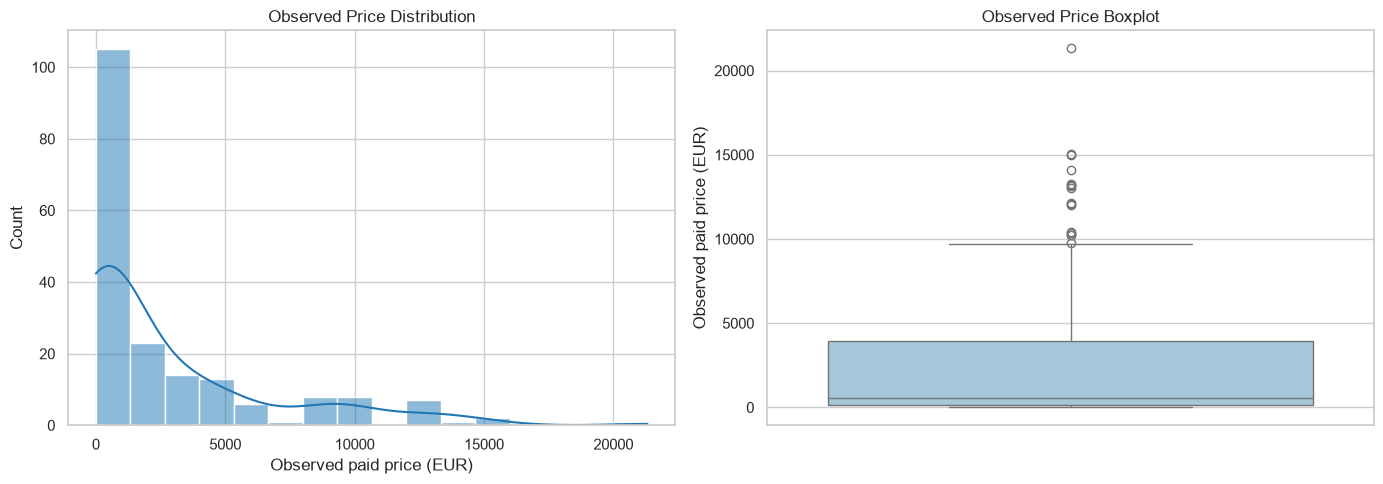

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["target"], kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Observed Price Distribution")
axes[0].set_xlabel("Observed paid price (EUR)")

sns.boxplot(y=df["target"], ax=axes[1], color="#9ecae1")
axes[1].set_title("Observed Price Boxplot")
axes[1].set_ylabel("Observed paid price (EUR)")

plt.tight_layout()

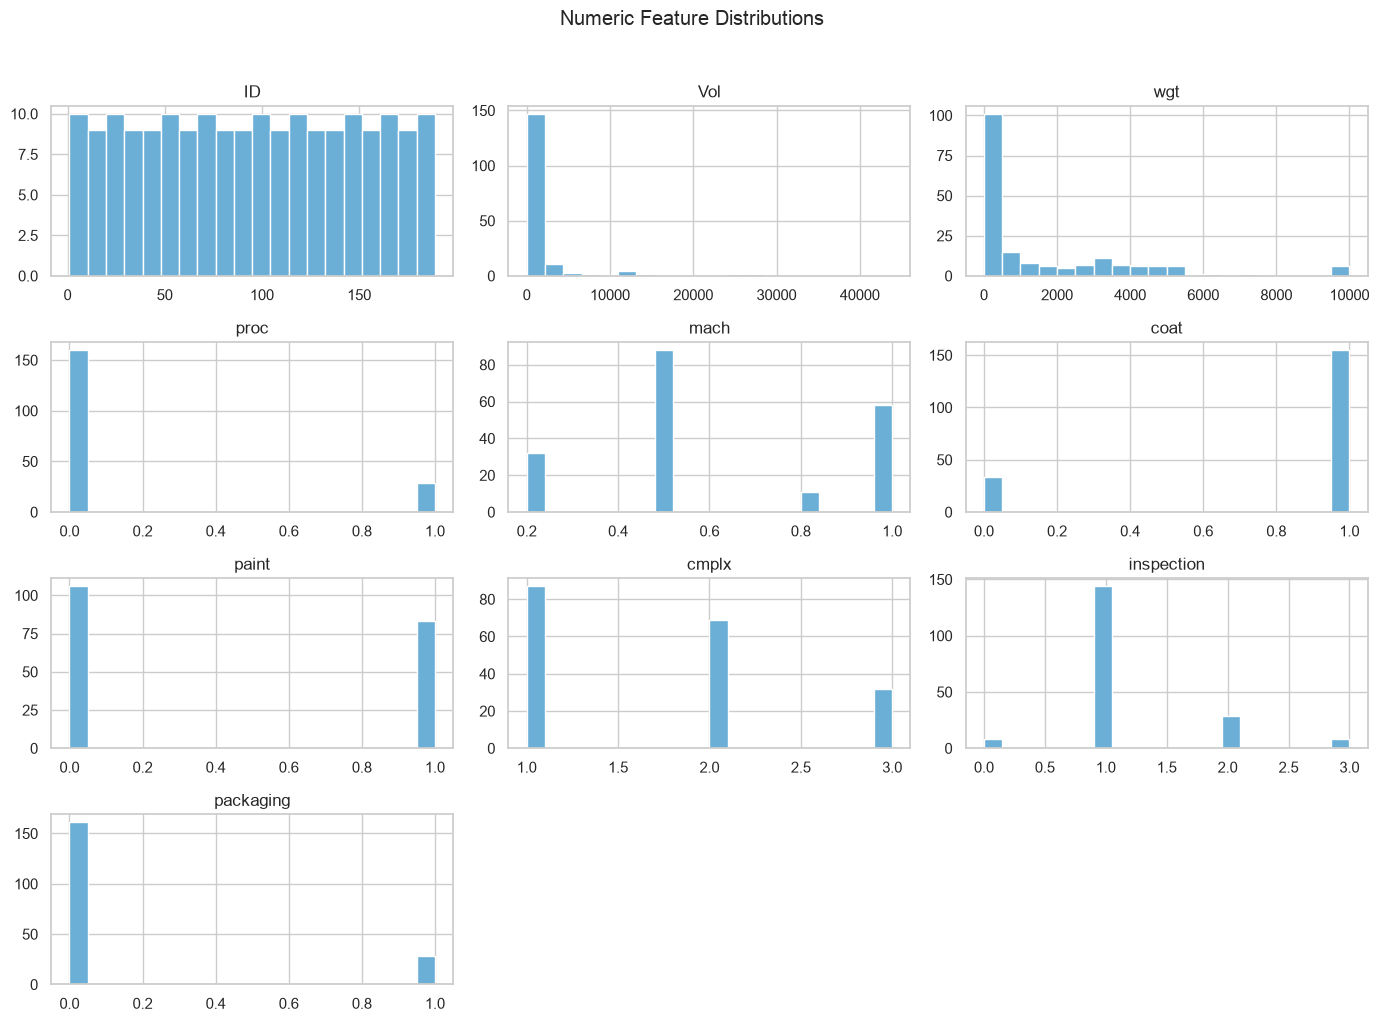

In [6]:
numeric_columns = df.select_dtypes(include="number").columns.tolist()
numeric_feature_columns = [col for col in numeric_columns if col != "target"]

df[numeric_feature_columns].hist(figsize=(14, 10), bins=20, layout=(4, 3), color="#6baed6")
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()

,corr_with_target
target,1.000000
wgt,0.777813
cmplx,0.561652
ID,0.234282
coat,0.230354
inspection,0.151153
proc,0.108541
paint,0.018691
packaging,-0.140918
Vol,-0.246555


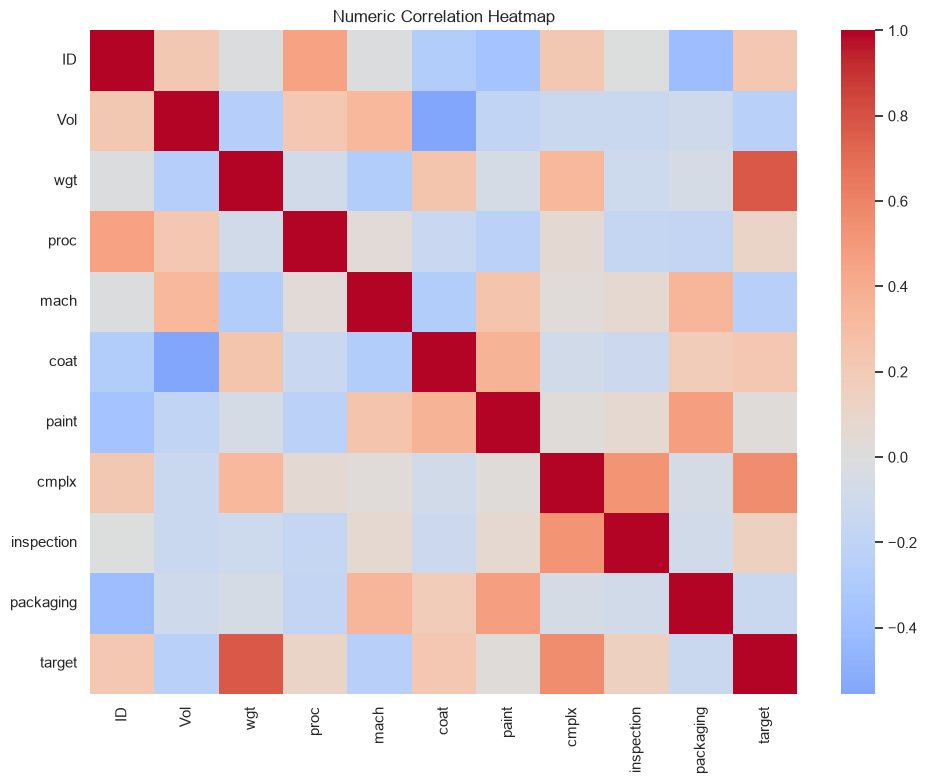

In [7]:
corr = df.select_dtypes(include="number").corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Numeric Correlation Heatmap")
plt.tight_layout()

corr["target"].sort_values(ascending=False).to_frame("corr_with_target")

In [8]:
categorical_columns = df.select_dtypes(exclude="number").columns.tolist()
for column in categorical_columns:
    display(df[column].value_counts(dropna=False).to_frame("count").head(15))

,count
Material,
EN-GJL-300,50
ASTM 148,28
ASTM 487 GR 4,12
EN-GJL-150,11
GS-22NiMoCr56,9
ASTM A216 GRADE WCC S11,8
ASTM A29 Grade 4140,7
EN-GJL-100,6
EN-GJS-500-7,6


,count
Type of casting,
2,89
1,85
3,15


In [9]:
duplicate_summary = pd.DataFrame(
    {
        "metric": [
            "full row duplicates",
            "feature duplicates excluding ID and target",
            "duplicate IDs",
        ],
        "value": [
            df.duplicated().sum(),
            df.drop(columns=["ID", "target"]).duplicated().sum(),
            df["ID"].duplicated().sum(),
        ],
    }
)
duplicate_summary

,metric,value
0,full row duplicates,0
1,feature duplicates excluding ID and target,29
2,duplicate IDs,0


## Notes

- Parsing uses the project loader, which handles semicolon-separated input, comma decimals, period thousands, and literal `na` values.
- `Material` and `Type of casting` are currently treated as categorical features.
- `ID` is preserved for inspection, but it should be excluded from modeling because it is an identifier rather than a predictive feature.